In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
os.listdir('/content/drive/MyDrive/2TI4 kelompok ')

['netflix_titles.csv']

In [40]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/2TI4 kelompok /netflix_titles.csv')

# Menampilkan 5 data pertama
df.head()

# Informasi dataset
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [41]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [42]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Step 1: Data Loading and Preliminary Exploration

**1.1 Import Libraries:** Load necessary libraries, typically Python's pandas, numpy, matplotlib, and seaborn.

**1.2 Load Dataset:** Read the CSV file into a pandas DataFrame.

**1.3 Initial Inspection:** Use .head(), .info(), and .describe() to understand column types and summary statistics.

In [44]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/2TI4 kelompok /netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [46]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Step 2: Data Cleaning and Preprocessing

**2.1 Handle Missing Values:** Identify columns with missing data (.isnull().sum()). Common strategies include dropping rows (if minimal missingness) or filling them with techniques like imputation (e.g., filling missing director with "Unknown").

**2.2 Remove Duplicates:** Remove redundant entries using .drop_duplicates().

**2.3 Data Type Conversion:** Convert columns like date_added to datetime objects and ensure release_year is numerical.

In [47]:
# Identify the number of columns with missing data

missing_columns = df.isnull().any().sum()
print(missing_columns)

# Identify which columns have missing values
df.isnull().any()

6


,0
show_id,False
type,False
title,False
director,True
cast,True
country,True
date_added,True
release_year,False
rating,True
duration,True


In [48]:
# Display the contents of the DataFrame in the output
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [49]:
# Drop rows where at least one value is missing
df = df.dropna()

print(df)

     show_id     type                          title             director  \
7         s8    Movie                        Sankofa         Haile Gerima   
8         s9  TV Show  The Great British Baking Show      Andy Devonshire   
9        s10    Movie                   The Starling       Theodore Melfi   
12       s13    Movie                   Je Suis Karl  Christian Schwochow   
24       s25    Movie                          Jeans           S. Shankar   
...      ...      ...                            ...                  ...   
8801   s8802    Movie                        Zinzana      Majid Al Ansari   
8802   s8803    Movie                         Zodiac        David Fincher   
8804   s8805    Movie                     Zombieland      Ruben Fleischer   
8805   s8806    Movie                           Zoom         Peter Hewitt   
8806   s8807    Movie                         Zubaan          Mozez Singh   

                                                   cast  \
7     Kofi Ghana

In [50]:
# Check for number of duplicate entries
duplicates = df.duplicated().sum()
print(duplicates)

0


In [51]:
# Check date_added data type and format:

df['date_added'].head()

,date_added
7,"September 24, 2021"
8,"September 24, 2021"
9,"September 24, 2021"
12,"September 23, 2021"
24,"September 21, 2021"


In [52]:
# Convert the date_added column to datetime format:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['date_added'].head()

,date_added
7,2021-09-24
8,2021-09-24
9,2021-09-24
12,2021-09-23
24,2021-09-21


# Step 3: Exploratory Data Analysis & Visualization

**3.1 Content Type Analysis:** Use count plots to compare the number of movies versus TV shows on the platform.

**3.2 Temporal Trends:** Analyze the growth of content over time using line plots of release_year and date_added.

**3.3 Geographical Analysis:** Visualize the top 10 countries producing content on Netflix using bar charts.

**3.4 Genre and Rating Analysis:** Analyze the most common genres using word clouds or bar charts and explore content distribution by rating to identify the most common audience age restrictions.

**3.5 Duration Analysis:** Analyze movie runtime distribution (minutes) vs. TV show seasons.

In [53]:
# Count the number of TV Shows vs Movies
df['type'].value_counts().to_frame()

,count
type,
Movie,5185
TV Show,147


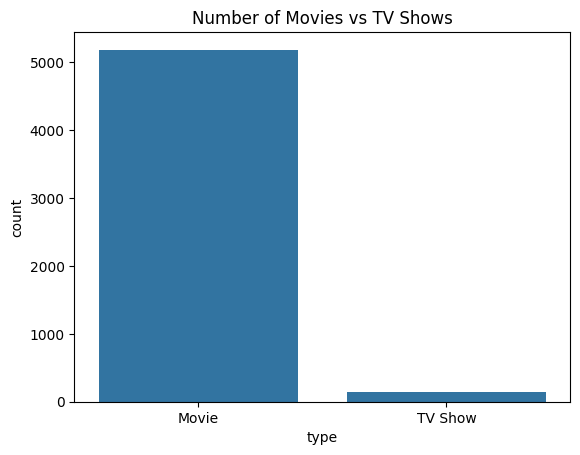

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for Movies vs TV Shows
sns.countplot(data=df, x='type')

# Add labels and title
plt.title('Number of Movies vs TV Shows')
plt.xlabel('type')
plt.ylabel('count')

plt.show()

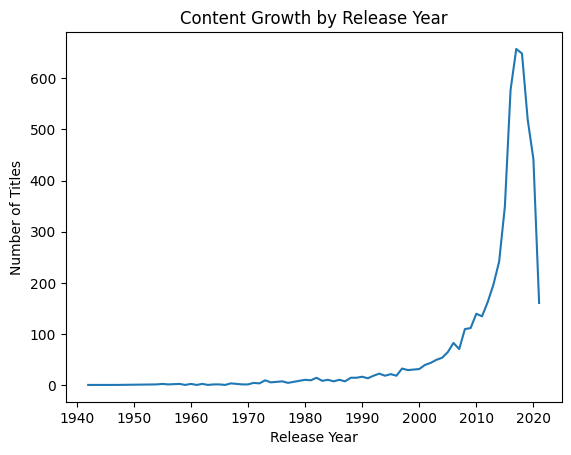

In [55]:
import matplotlib.pyplot as plt

# Count number of titles per release year
release_counts = df['release_year'].value_counts().sort_index()

# Plot
plt.figure()
plt.plot(release_counts.index, release_counts.values)

plt.title('Content Growth by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

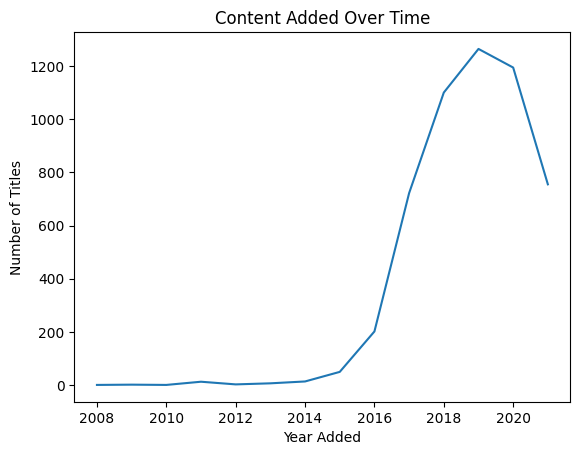

In [56]:
# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year added
df['year_added'] = df['date_added'].dt.year

# Count titles added per year
added_counts = df['year_added'].value_counts().sort_index()

# Plot
plt.figure()
plt.plot(added_counts.index, added_counts.values)

plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

Text(0, 0.5, 'Number of Titles')

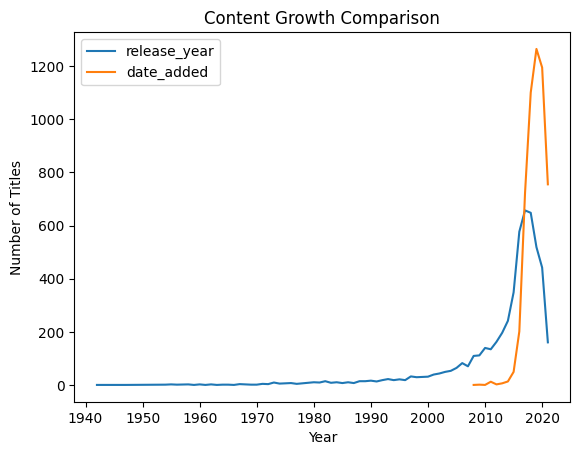

In [57]:
plt.figure()

plt.plot(release_counts.index, release_counts.values, label='release_year')
plt.plot(added_counts.index, added_counts.values, label='date_added')

plt.legend()
plt.title('Content Growth Comparison')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

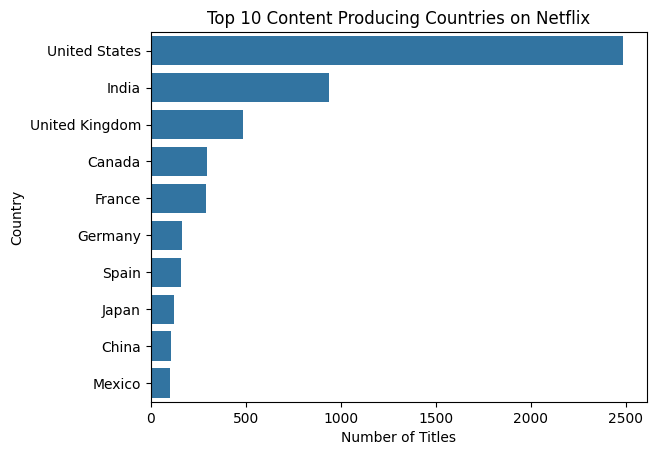

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Drop missing values
df_country = df.dropna(subset=['country'])

# Split multiple countries and explode into rows
df_country = df_country.assign(country=df_country['country'].str.split(', '))
df_country = df_country.explode('country')

# Get top 10 countries
top_countries = df_country['country'].value_counts().head(10)

# Plot
plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title('Top 10 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

/tmp/ipykernel_3689/1789916943.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set2')


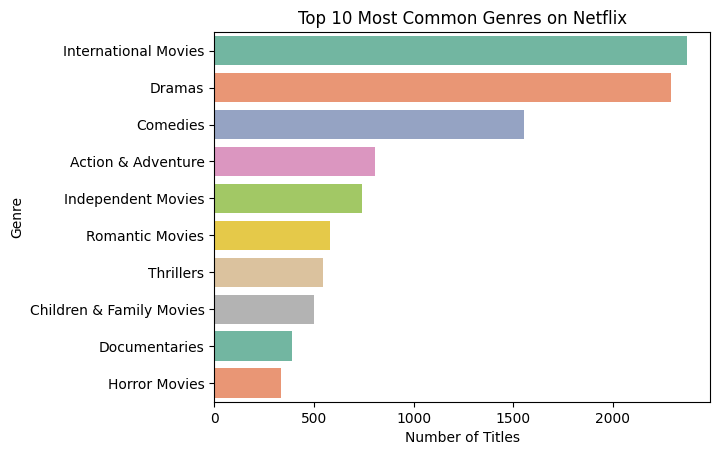

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create df_genre
df_genre = df.dropna(subset=['listed_in'])

# Step 2: Split and explode genres
df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('listed_in')

# Step 3: Count top genres
top_genres = df_genre['listed_in'].value_counts().head(10)

# Step 4: Plot
plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set2')

plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

In [60]:
# This code shows how many titles fall under each rating
df['rating'].value_counts().to_frame()

,count
rating,
TV-MA,1822
TV-14,1214
R,778
PG-13,470
TV-PG,431
PG,275
TV-G,84
TV-Y7,76
TV-Y,76


/tmp/ipykernel_3689/1453526959.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Set3')


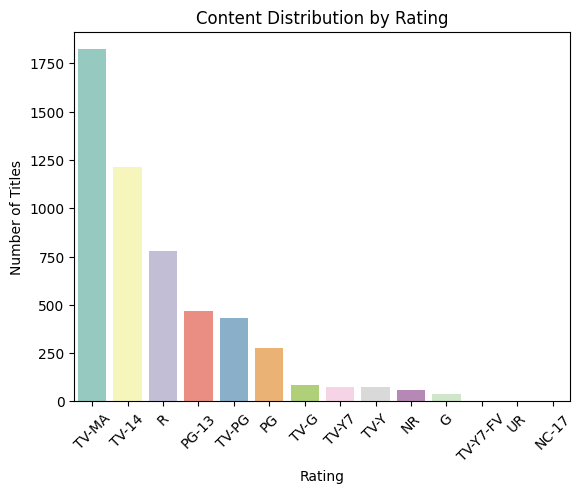

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count ratings
rating_counts = df['rating'].value_counts()

# Plot
plt.figure()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Set3')

plt.title('Content Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3689/342138091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='coolwarm')


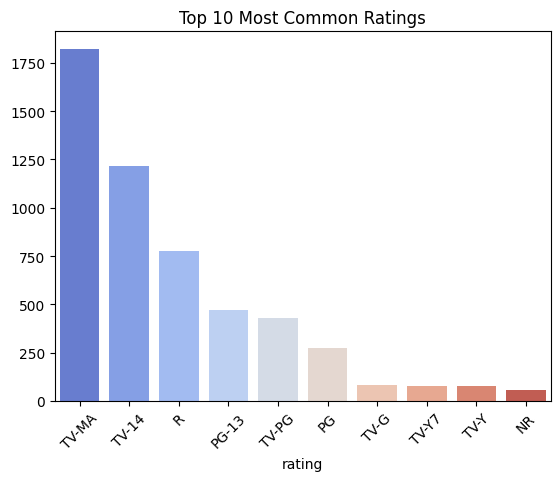

In [62]:
top_ratings = df['rating'].value_counts().head(10)

sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='coolwarm')
plt.xticks(rotation=45)

plt.title('Top 10 Most Common Ratings')
plt.show()

In [63]:
# Percentage distribution
rating_percent = df['rating'].value_counts(normalize=True) * 100
print(rating_percent.round(2))

rating
TV-MA       34.17
TV-14       22.77
R           14.59
PG-13        8.81
TV-PG        8.08
PG           5.16
TV-G         1.58
TV-Y7        1.43
TV-Y         1.43
NR           1.09
G            0.75
TV-Y7-FV     0.06
UR           0.06
NC-17        0.04
Name: proportion, dtype: float64


In [64]:
# Split dataset
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

In [65]:
# Extract movie duration (in minutes)
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)

# Extract number of seasons
tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3689/4080139479.py:2: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_3689/4080139479.py:5: SyntaxWarning: invalid escape sequence '\d'
  tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)


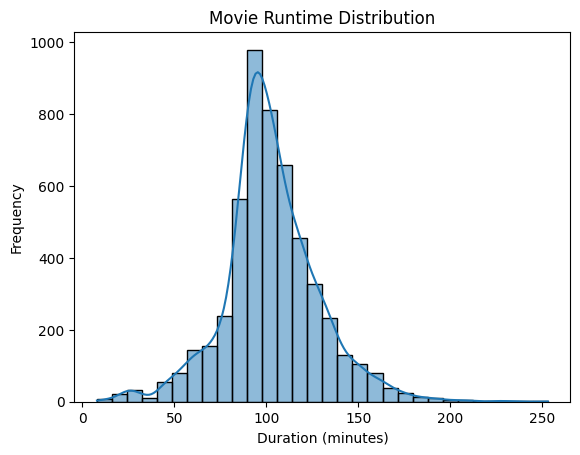

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(movies['duration_min'], bins=30, kde=True)

plt.title('Movie Runtime Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')

plt.show()

/tmp/ipykernel_3689/1916237631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=tv_shows['seasons'], palette='Set2')


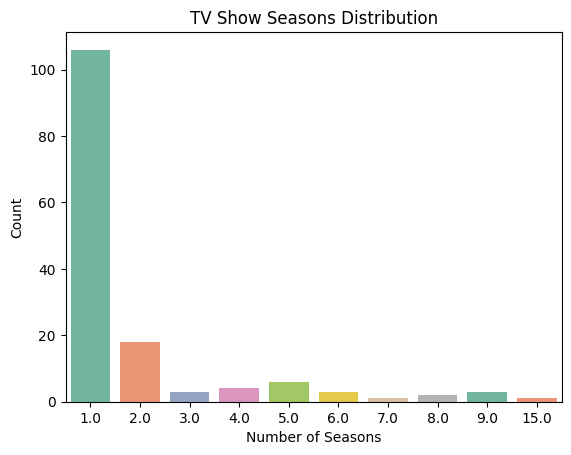

In [67]:
plt.figure()
sns.countplot(x=tv_shows['seasons'], palette='Set2')

plt.title('TV Show Seasons Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')

plt.show()

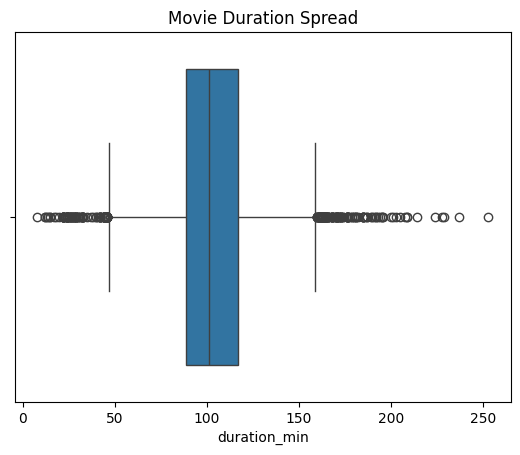

In [68]:
plt.figure()

sns.boxplot(data=movies, x='duration_min')
plt.title('Movie Duration Spread')

plt.show()

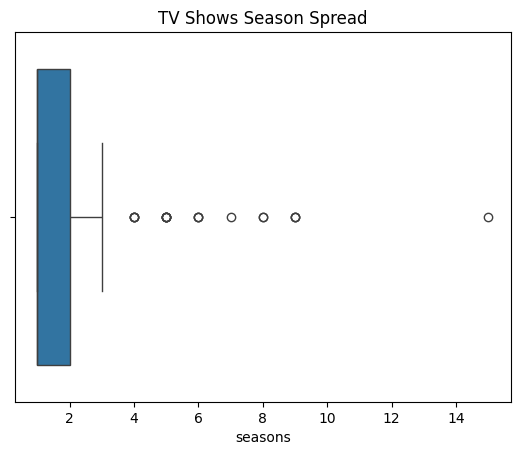

In [69]:
plt.figure()

sns.boxplot(data=tv_shows, x='seasons')
plt.title('TV Shows Season Spread')

plt.show()